# EDA (Analisis Exploratorio de Datos)

In [1]:
import pandas as pd

In [2]:
raw_data = pd.read_csv('../data/housing/housing.csv')

In [3]:
raw_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
raw_data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
raw_data.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [7]:
raw_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
raw_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
from pathlib import Path
import matplotlib.pyplot as plt

In [11]:
path_images = Path() / 'images'
path_images.mkdir(exist_ok=True)

def save_fig(name, extension = 'png', resolution = 300):
    path_final = path_images / f'{name}.{extension}'
    plt.tight_layout()

    plt.savefig(path_final, format=extension, dpi=resolution)

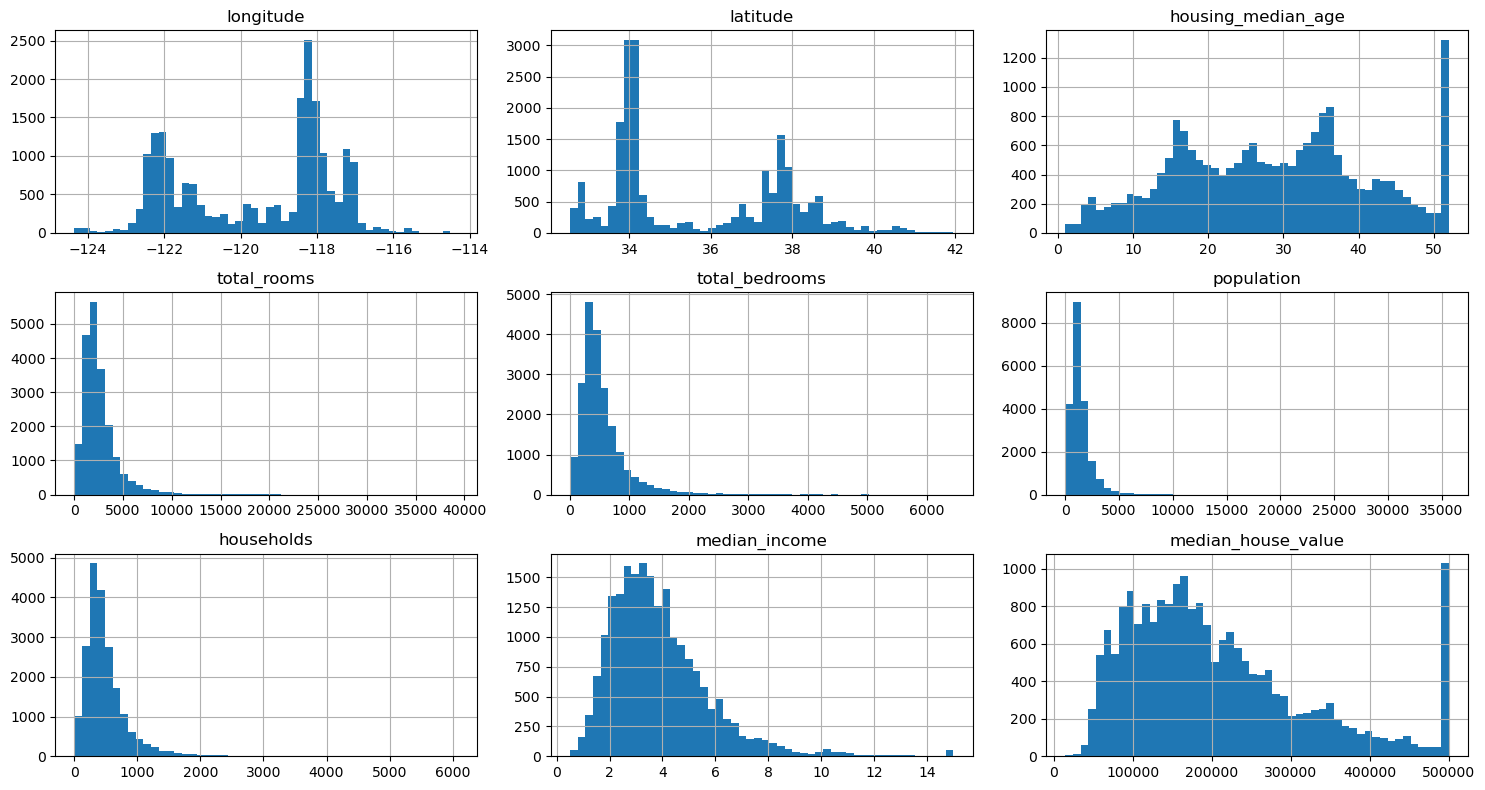

In [17]:
raw_data.hist(bins= 50, figsize=(15,8))
save_fig('distribuciones_atributos')
plt.show()

In [22]:
columnas_numericas = list(raw_data.columns)[:-1]

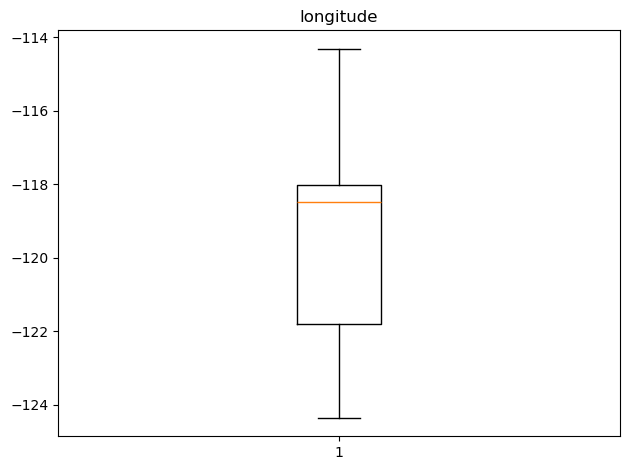

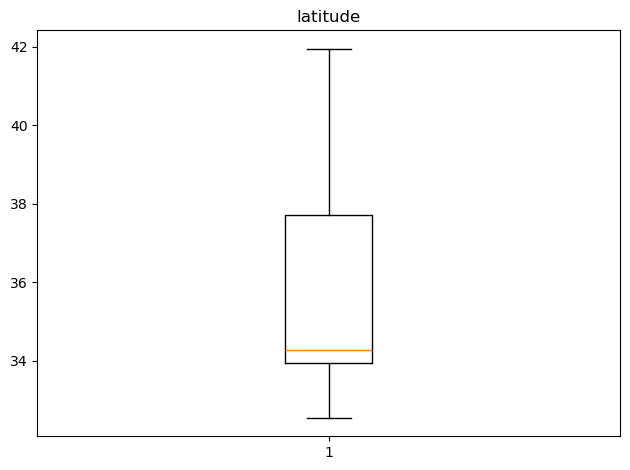

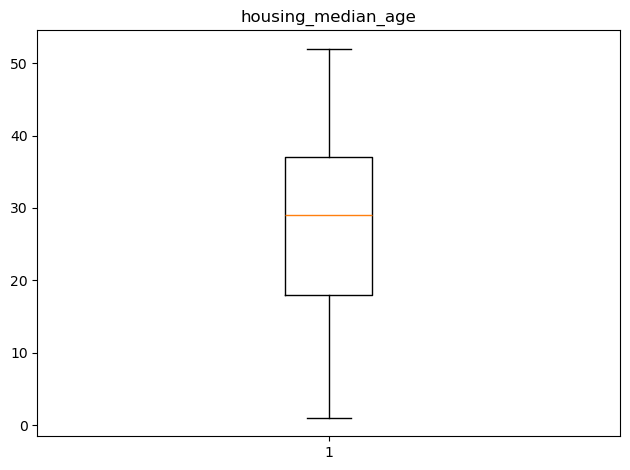

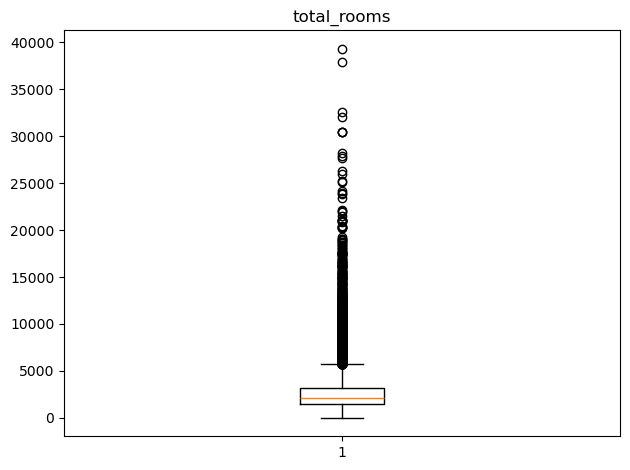

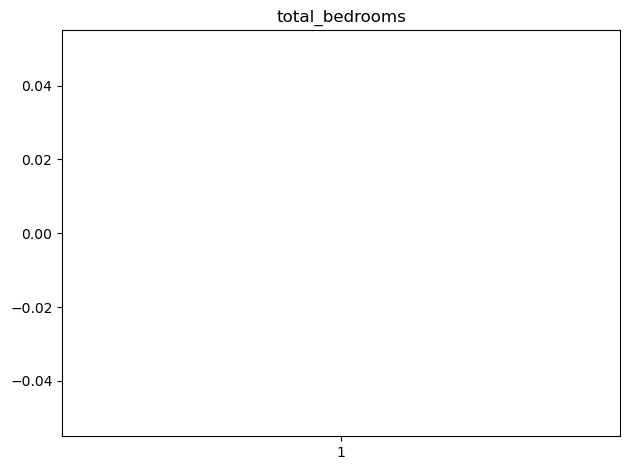

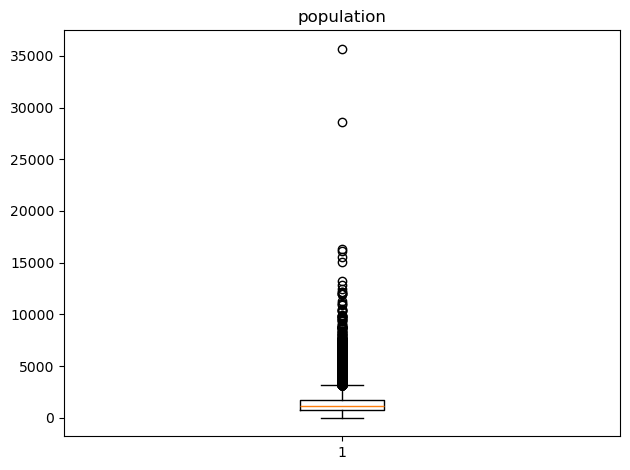

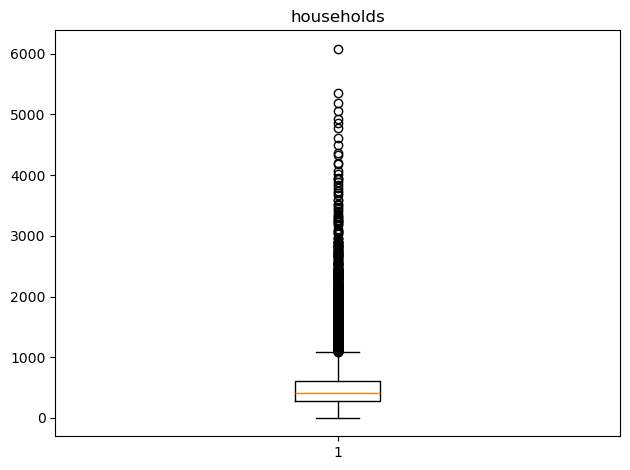

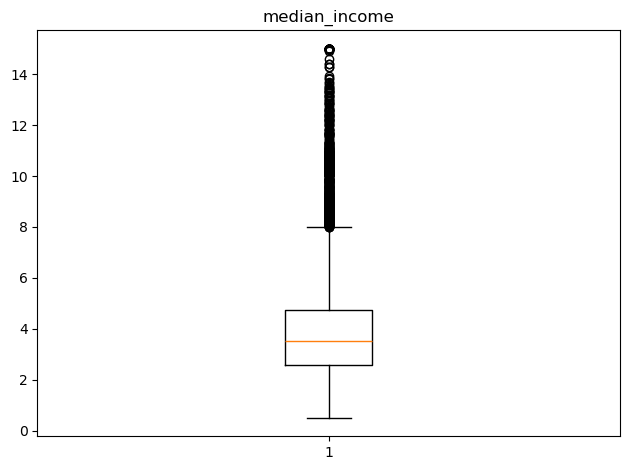

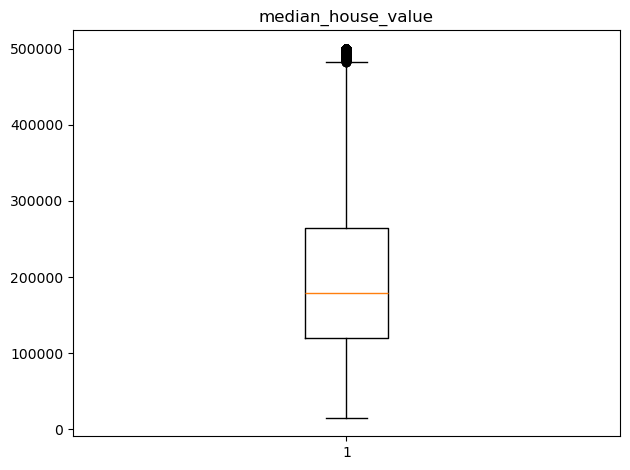

In [26]:
for col_nums in columnas_numericas:
    plt.boxplot(raw_data[col_nums])
    plt.title(f'{col_nums}')
    save_fig(f'{col_nums}_boxplot')
    plt.show()

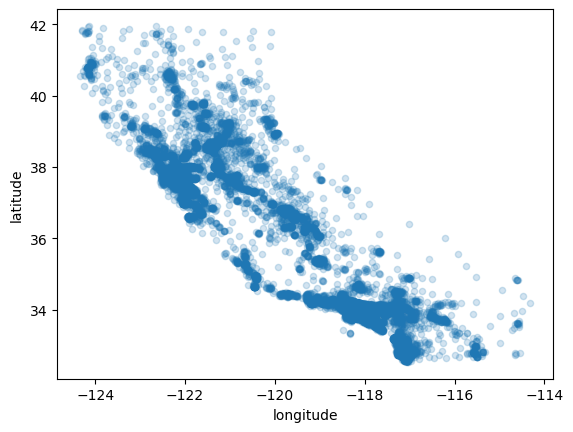

In [31]:
raw_data.plot(kind='scatter', x='longitude', y='latitude', alpha=0.2)
plt.show()

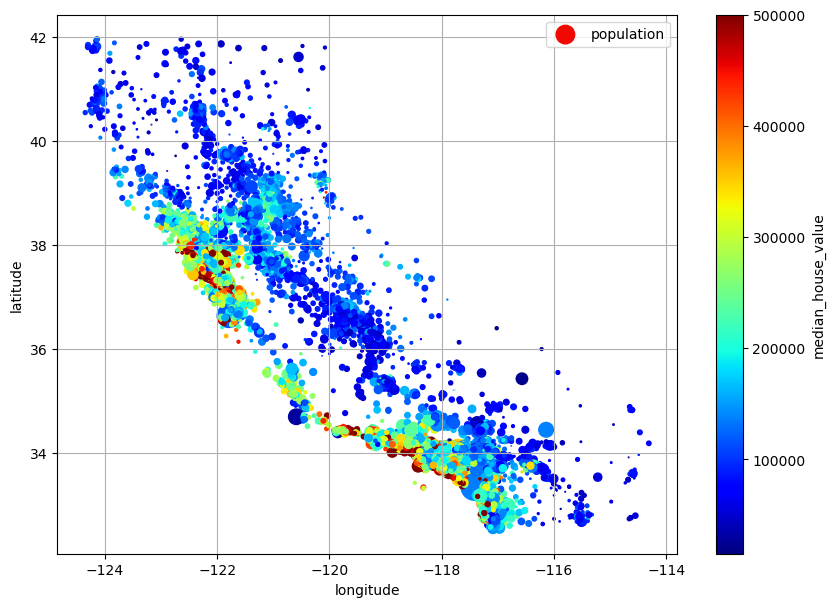

In [35]:
raw_data.plot(
    kind='scatter', x='longitude', y='latitude', grid=True,
    s=raw_data['population'] / 100, label ='population',
    c='median_house_value', cmap='jet' ,colorbar=True,
    legend=True, figsize=(10,7)
)
plt.show()

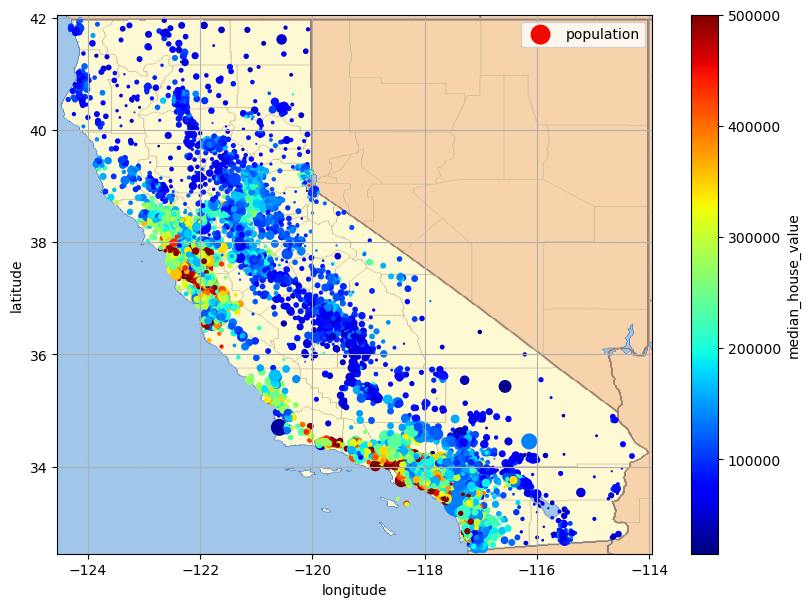

In [47]:
imagen = plt.imread('./images/california.png')

raw_data.plot(
    kind='scatter', x='longitude', y='latitude', grid=True,
    s=raw_data['population'] / 100, label ='population',
    c='median_house_value', cmap='jet' ,colorbar=True,
    legend=True, figsize=(10,7), sharex=False
)

axis = -124.55, -113.95, 32.45, 42.05

plt.axis(axis)

plt.imshow(imagen, extent=axis)

plt.show()

In [48]:
matriz_corr = raw_data.corr(numeric_only=True)

In [49]:
matriz_corr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [50]:
matriz_corr['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [51]:
raw_data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

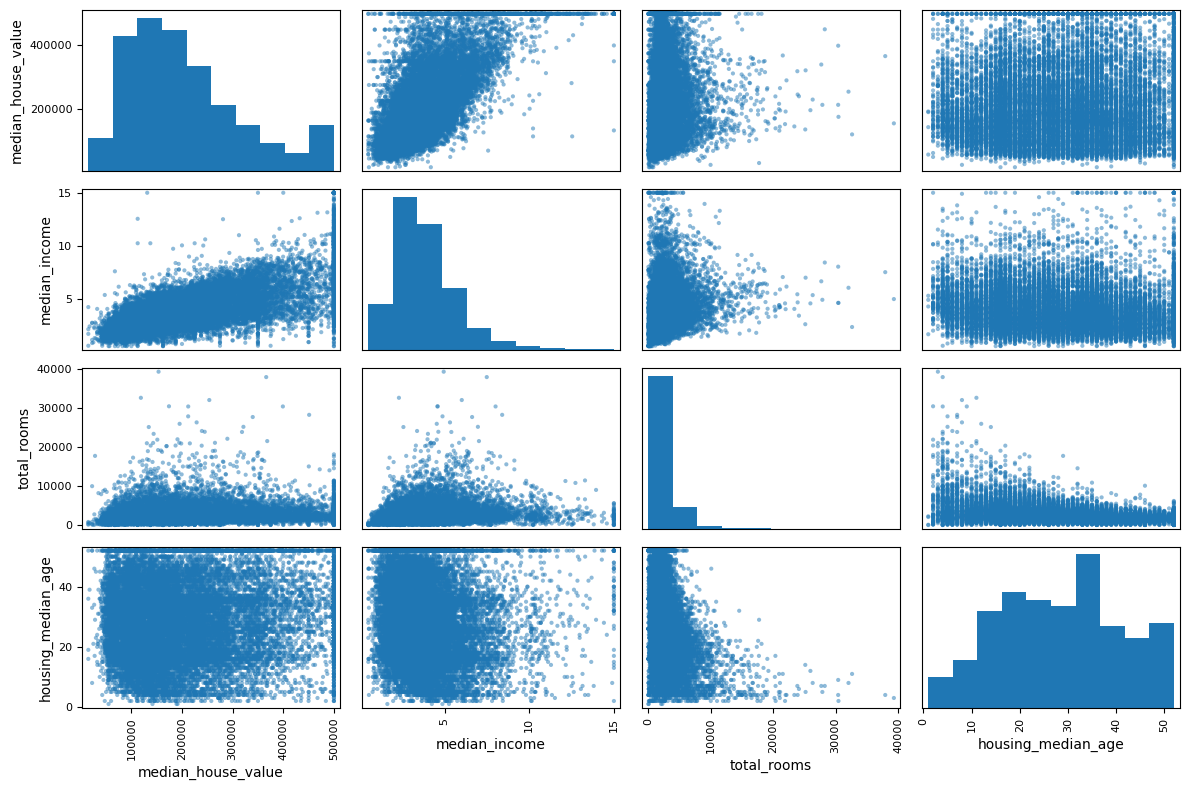

In [53]:
from pandas.plotting import scatter_matrix

atributos = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

scatter_matrix(raw_data[atributos], figsize=(12,8))
save_fig('matrix_de_dispersion_grafico')
plt.show()

In [54]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [55]:
raw_data['personas_por_casa'] = raw_data['population'] / raw_data['households']

In [57]:
raw_data['cuartos_por_casa'] = raw_data['total_rooms'] / raw_data['households']
raw_data['ratio_de_habitaciones'] = raw_data['total_bedrooms'] / raw_data['total_rooms']


In [58]:
corr_con_nuevas_metricas = raw_data.corr(numeric_only=True)
corr_con_nuevas_metricas['median_house_value'].sort_values(ascending=False)

median_house_value       1.000000
median_income            0.688075
cuartos_por_casa         0.151948
total_rooms              0.134153
housing_median_age       0.105623
households               0.065843
total_bedrooms           0.049686
personas_por_casa       -0.023737
population              -0.024650
longitude               -0.045967
latitude                -0.144160
ratio_de_habitaciones   -0.255880
Name: median_house_value, dtype: float64

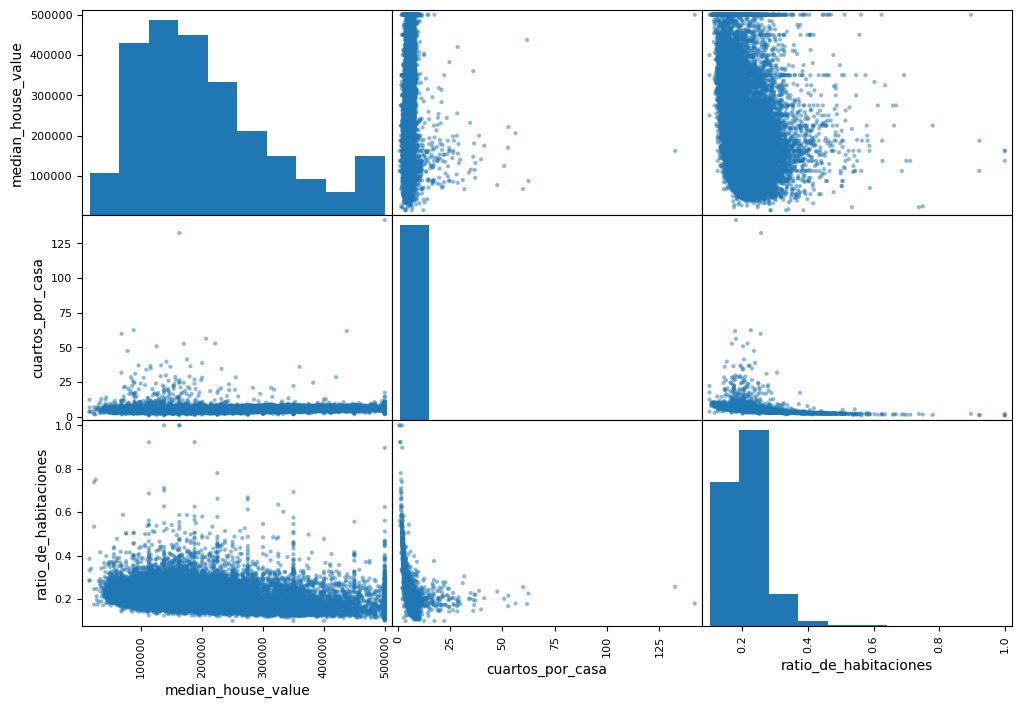

In [60]:
from pandas.plotting import scatter_matrix

atributos = ['median_house_value', 'cuartos_por_casa', 'ratio_de_habitaciones']

scatter_matrix(raw_data[atributos], figsize=(12,8))
plt.show()